# 02 — Deep Q-Network on 2048

**Architecture.** `Linear(256, 512) → ReLU → Linear(512, 256) → ReLU → Linear(256, 4)`.

**Inputs.** One-hot log2 over the 16 cells × 16 buckets = 256 floats. Lets the network learn its own features rather than receiving the n-tuple's hand-engineered ones — preserving the central representation comparison.

**Loss.** Smooth-L1 on the **Double-DQN** target: `r + γ · Q_target(s', argmax_a Q_online(s', a))` with **action masking** in both the argmax (online) and the bootstrap (target). Reward is scaled by 0.1 to keep the value head in a numerically friendly range (raw reward in [1, 15]).

**Hyperparams.** Adam(lr=5e-4), γ=0.99, target sync every 1000 grad steps, ε linearly 1.0 → 0.05 over the first 70 % of episodes.

Runs ~5 k episodes (~25 min on MPS). Bump `EPISODES` to 50_000 for a publication-grade run; the checkpoint at `data/checkpoints/dqn/latest.pt` will be picked up by Notebook 04 either way.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import set_seed, pick_device, CKPT_DIR, LOG_DIR, EVAL_DIR
from src.agents.dqn import DQNAgent
from src.training.train_dqn import train_dqn
from src.eval.evaluate import run_eval, save_eval

set_seed(42)
sns.set_theme()
plt.rcParams['figure.dpi'] = 110
DEVICE = pick_device()
print('device:', DEVICE)

DQN_CKPT_DIR = CKPT_DIR / 'dqn'
DQN_LOG = LOG_DIR / 'dqn.csv'

device: mps


In [2]:
EPISODES = 5_000

agent = DQNAgent(device=DEVICE,
                  eps_decay_episodes=int(EPISODES * 0.7),
                  reward_scale=0.1,
                  double_dqn=True)
ckpt_path = train_dqn(agent, episodes=EPISODES, log_path=DQN_LOG,
                      ckpt_dir=DQN_CKPT_DIR, ckpt_every=max(EPISODES // 5, 100),
                      verbose=True)
print('saved:', ckpt_path)

ep    100 | avg100    294.4 | max_tile    64 | eps 0.973


ep    200 | avg100    317.1 | max_tile    64 | eps 0.946


ep    300 | avg100    307.2 | max_tile    64 | eps 0.919


ep    400 | avg100    322.0 | max_tile   128 | eps 0.891


ep    500 | avg100    309.5 | max_tile    64 | eps 0.864


...

ep   4600 | avg100    321.1 | max_tile    64 | eps 0.050


ep   4700 | avg100    303.6 | max_tile   256 | eps 0.050


ep   4800 | avg100    299.5 | max_tile    64 | eps 0.050


ep   4900 | avg100    288.7 | max_tile    64 | eps 0.050


ep   5000 | avg100    293.8 | max_tile    32 | eps 0.050
saved: /Users/florianrobrecht/Documents/006_GitHub/Machine-Learning-2/Assignment 5/data/checkpoints/dqn/latest.pt


## Training curves

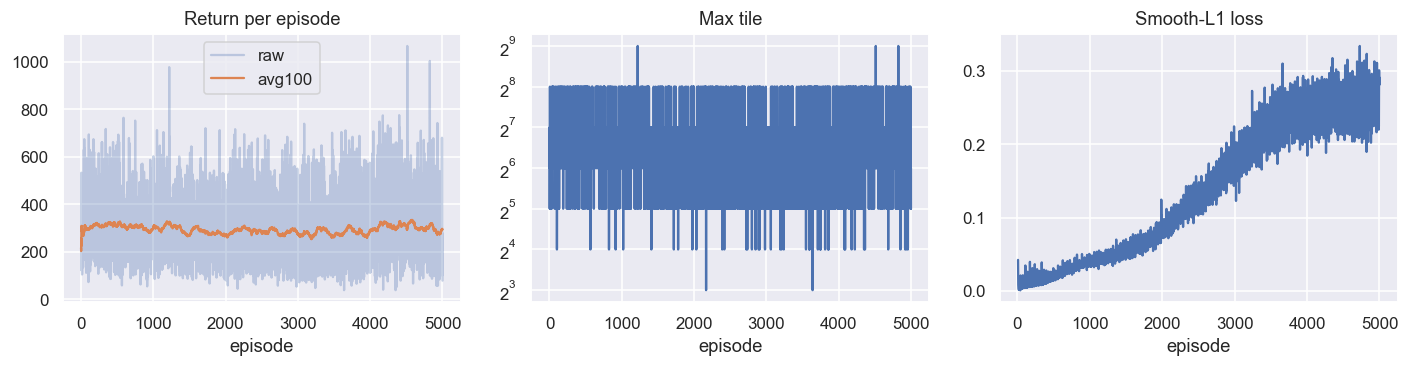

In [3]:
log_df = pd.read_csv(DQN_LOG)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(log_df['episode'], log_df['return'], alpha=0.3, label='raw')
axes[0].plot(log_df['episode'], log_df['return'].rolling(100, min_periods=1).mean(), label='avg100')
axes[0].set_title('Return per episode'); axes[0].legend()
axes[1].plot(log_df['episode'], log_df['max_tile']); axes[1].set_yscale('log', base=2); axes[1].set_title('Max tile')
axes[2].plot(log_df['episode'], pd.to_numeric(log_df['loss_or_td_error'], errors='coerce'))
axes[2].set_title('Smooth-L1 loss')
for ax in axes: ax.set_xlabel('episode')
fig.tight_layout()

## Reload + greedy eval

In [4]:
eval_agent = DQNAgent(device=DEVICE)
eval_agent.load(ckpt_path)
metrics = run_eval(eval_agent, n_games=300, seed=0, train_log=DQN_LOG)
save_eval(metrics, EVAL_DIR / 'eval_dqn.json')
metrics

{'agent': 'dqn',
 'n_games': 300,
 'mean_score': 310.55,
 'median_score': 295.5,
 'max_score': 644,
 'mean_max_tile': 109.44,
 'max_max_tile': 256,
 'pct_reaching': {'512': 0.0,
  '1024': 0.0,
  '2048': 0.0,
  '4096': 0.0,
  '8192': 0.0},
 'mean_steps': 123.56,
 'episodes_to_first_1024': None,
 'episodes_to_first_2048': None}